In [38]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from datetime import datetime
from time import strftime

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

In [39]:
import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))

[]


## Preprocesamiento de Datos

El Dataset que se uso en este proyecto es CMAPSS Jet Engine Simulated Data, el cual se puede encontrar https://data.nasa.gov/dataset/cmapss-jet-engine-simulated-data. Este conjunto de datos muestra los valores de los sensores de un motor de avión. La manera en que se separa este conjunto de datos es que el conjunto de entrenamiento tiene datos de los motores en una secuencia de tiempo hasta el momento justo antes de que este falle. Para la detección de anomalías se quiere entrenar el modelo solo con datos de motores buenos para que este aprenda a reconstruir dichos datos. En el momento de obtener datos de motores averiados, este detecte la anomalía y lo clasifique como tal.

In [40]:
data_dir = "./CMAPSSData"
print("data_dir:", data_dir)
assert os.path.exists(data_dir), f"data_dir not found: {data_dir}"

# common column names used by C-MAPSS
COL_NAMES = (['unit', 'cycle', 'op_setting_1', 'op_setting_2', 'op_setting_3'] +
             [f'sensor_{i+1}' for i in range(21)])

def discover_files(data_dir):
    """
    Return dict mapping FD ids ('FD001',...) to dicts with keys possibly 'train','test','rul'.
    This version is tolerant to filename variations and case.
    """
    mapping = {}
    for path in glob.glob(os.path.join(data_dir, "*")):
        name = os.path.basename(path).upper()
        # detect FD id present in filename
        for fd in ['FD001','FD002','FD003','FD004']:
            if fd in name:
                if fd not in mapping:
                    mapping[fd] = {}
                if 'TRAIN' in name:
                    mapping[fd]['train'] = path
                if 'TEST' in name:
                    mapping[fd]['test'] = path
                if 'RUL' in name or name.startswith('RUL_') or 'RUL' in name:
                    mapping[fd]['rul'] = path
                # also accept files named like 'train_FD001.txt' etc.
                # note: we allow multiple matches; last one wins (fine for typical datasets)
    return mapping

def load_cmapss_pair(train_path, test_path, rul_path):
    """Load a single FD dataset duo"""
    train = pd.read_csv(train_path, sep='\s+', header=None, names=COL_NAMES)

    test = pd.read_csv(test_path, sep='\s+', header=None, names=COL_NAMES)

    rul_test = pd.read_csv(rul_path, sep='\s+', header=None, names=['RUL'])

    train[['unit','cycle']] = train[['unit','cycle']].astype(int)
    test[['unit','cycle']] = test[['unit','cycle']].astype(int)
    rul_test['unit'] = np.arange(1,101)
    return train.reset_index(drop=True), test.reset_index(drop=True), rul_test.reset_index(drop=True)

# discover dataset files
mapping = discover_files(data_dir)
print("Discovered dataset keys and file types:")
for k,v in mapping.items():
    print(k, v.keys())

# --- Choose dataset FDID to run ---
FDID = 'FD001'

# If chosen FDID doesn't have train+test, pick the first available FD that has both
if FDID not in mapping or 'train' not in mapping[FDID] or 'test' not in mapping[FDID]:
    print(f"Requested {FDID} is missing train/test. Searching for first FD with both train and test...")
    chosen = None
    for fd, files in mapping.items():
        if 'train' in files and 'test' in files:
            chosen = fd
            break
    if chosen is None:
        raise FileNotFoundError(f"No FD dataset with both train and test found in {data_dir}. Mapping: {mapping}")
    print(f"Switching to available dataset: {chosen}")
    FDID = chosen

train_path = mapping[FDID]['train']
test_path  = mapping[FDID]['test']
rul_path = mapping[FDID]['rul']

print("Using:", train_path, test_path)
train_df, test_df, rul_df = load_cmapss_pair(train_path, test_path, rul_path)
print(f"Loaded {FDID}: train rows={len(train_df)} (units={train_df['unit'].nunique()}), test rows={len(test_df)} (units={test_df['unit'].nunique()})")

data_dir: ./CMAPSSData
Discovered dataset keys and file types:
FD001 dict_keys(['train', 'rul', 'test'])
FD003 dict_keys(['train', 'rul', 'test'])
FD004 dict_keys(['rul', 'train', 'test'])
FD002 dict_keys(['train', 'rul', 'test'])
Using: ./CMAPSSData/train_FD001.txt ./CMAPSSData/test_FD001.txt
Loaded FD001: train rows=20631 (units=100), test rows=13096 (units=100)


In [41]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20631 entries, 0 to 20630
Data columns (total 26 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   unit          20631 non-null  int64  
 1   cycle         20631 non-null  int64  
 2   op_setting_1  20631 non-null  float64
 3   op_setting_2  20631 non-null  float64
 4   op_setting_3  20631 non-null  float64
 5   sensor_1      20631 non-null  float64
 6   sensor_2      20631 non-null  float64
 7   sensor_3      20631 non-null  float64
 8   sensor_4      20631 non-null  float64
 9   sensor_5      20631 non-null  float64
 10  sensor_6      20631 non-null  float64
 11  sensor_7      20631 non-null  float64
 12  sensor_8      20631 non-null  float64
 13  sensor_9      20631 non-null  float64
 14  sensor_10     20631 non-null  float64
 15  sensor_11     20631 non-null  float64
 16  sensor_12     20631 non-null  float64
 17  sensor_13     20631 non-null  float64
 18  sensor_14     20631 non-nu

In [42]:
train_df.describe(include='all')

,unit,cycle,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,sensor_9,sensor_10,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
count,20631.000000,20631.000000,20631.000000,20631.000000,20631.0,20631.00,20631.000000,20631.000000,20631.000000,2.063100e+04,20631.000000,20631.000000,20631.000000,20631.000000,20631.0,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000,2.063100e+04,20631.000000,20631.0,20631.0,20631.000000,20631.000000
mean,51.506568,108.807862,-0.000009,0.000002,100.0,518.67,642.680934,1590.523119,1408.933782,1.462000e+01,21.609803,553.367711,2388.096652,9065.242941,1.3,47.541168,521.413470,2388.096152,8143.752722,8.442146,3.000000e-02,393.210654,2388.0,100.0,38.816271,23.289705
std,29.227633,68.880990,0.002187,0.000293,0.0,0.00,0.500053,6.131150,9.000605,1.776400e-15,0.001389,0.885092,0.070985,22.082880,0.0,0.267087,0.737553,0.071919,19.076176,0.037505,1.387812e-17,1.548763,0.0,0.0,0.180746,0.108251
min,1.000000,1.000000,-0.008700,-0.000600,100.0,518.67,641.210000,1571.040000,1382.250000,1.462000e+01,21.600000,549.850000,2387.900000,9021.730000,1.3,46.850000,518.690000,2387.880000,8099.940000,8.324900,3.000000e-02,388.000000,2388.0,100.0,38.140000,22.894200
25%,26.000000,52.000000,-0.001500,-0.000200,100.0,518.67,642.325000,1586.260000,1402.360000,1.462000e+01,21.610000,552.810000,2388.050000,9053.100000,1.3,47.350000,520.960000,2388.040000,8133.245000,8.414900,3.000000e-02,392.000000,2388.0,100.0,38.700000,23.221800
50%,52.000000,104.000000,0.000000,0.000000,100.0,518.67,642.640000,1590.100000,1408.040000,1.462000e+01,21.610000,553.440000,2388.090000,9060.660000,1.3,47.510000,521.480000,2388.090000,8140.540000,8.438900,3.000000e-02,393.000000,2388.0,100.0,38.830000,23.297900
75%,77.000000,156.000000,0.001500,0.000300,100.0,518.67,643.000000,1594.380000,1414.555000,1.462000e+01,21.610000,554.010000,2388.140000,9069.420000,1.3,47.700000,521.950000,2388.140000,8148.310000,8.465600,3.000000e-02,394.000000,2388.0,100.0,38.950000,23.366800
max,100.000000,362.000000,0.008700,0.000600,100.0,518.67,644.530000,1616.910000,1441.490000,1.462000e+01,21.610000,556.060000,2388.560000,9244.590000,1.3,48.530000,523.380000,2388.560000,8293.720000,8.584800,3.000000e-02,400.000000,2388.0,100.0,39.430000,23.618400


Se puede notar que op_setting_3, sensor_1, sensor_10, sensor_18 y sensor_19 siempre se mantiene constante, por lo que no aporta ninguna información

In [43]:
rul_df.loc[rul_df['unit']==1]['RUL'].item()

112

In [44]:
def calculate_rul(df, unit_col='unit', cycle_col='cycle', is_test=False, test_rul=None):
    """Calculate RUL for dataset"""
    rul_values = []
    
    for engine_id in df[unit_col].unique():
        engine_data = df[df[unit_col] == engine_id].copy()
        if is_test:
            max_cycle = engine_data[cycle_col].max() + test_rul.loc[test_rul['unit'] == engine_id, 'RUL'].item()
        else:
            max_cycle = engine_data[cycle_col].max()
        engine_data['RUL'] = max_cycle - engine_data[cycle_col]
        rul_values.append(engine_data)
    
    return pd.concat(rul_values, ignore_index=True)

In [45]:
train_df = calculate_rul(train_df)
test_df = calculate_rul(test_df, is_test=True, test_rul=rul_df)

In [46]:
train_df = pd.concat([train_df, test_df], ignore_index=True)

In [47]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33727 entries, 0 to 33726
Data columns (total 27 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   unit          33727 non-null  int64  
 1   cycle         33727 non-null  int64  
 2   op_setting_1  33727 non-null  float64
 3   op_setting_2  33727 non-null  float64
 4   op_setting_3  33727 non-null  float64
 5   sensor_1      33727 non-null  float64
 6   sensor_2      33727 non-null  float64
 7   sensor_3      33727 non-null  float64
 8   sensor_4      33727 non-null  float64
 9   sensor_5      33727 non-null  float64
 10  sensor_6      33727 non-null  float64
 11  sensor_7      33727 non-null  float64
 12  sensor_8      33727 non-null  float64
 13  sensor_9      33727 non-null  float64
 14  sensor_10     33727 non-null  float64
 15  sensor_11     33727 non-null  float64
 16  sensor_12     33727 non-null  float64
 17  sensor_13     33727 non-null  float64
 18  sensor_14     33727 non-nu

In [48]:
# Si se usa FD003, sensor 10 si es importante
train_df.drop(['op_setting_3', 'sensor_1', 'sensor_18', 'sensor_19'], axis=1, inplace=True)
units = train_df['unit'].nunique()

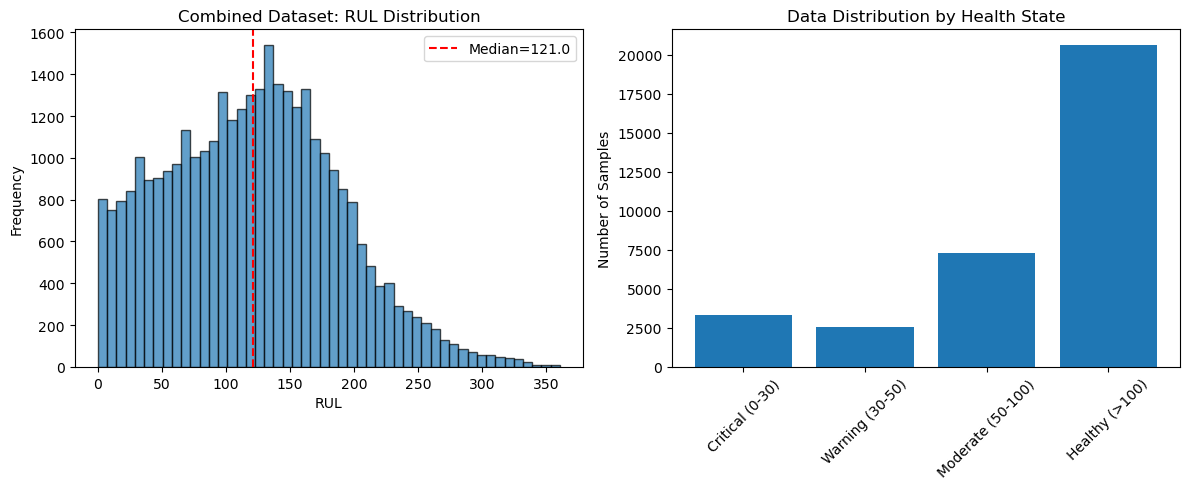

In [49]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.hist(train_df['RUL'], bins=50, edgecolor='black', alpha=0.7)
plt.xlabel('RUL')
plt.ylabel('Frequency')
plt.title('Combined Dataset: RUL Distribution')
plt.axvline(train_df['RUL'].median(), color='red', linestyle='--', 
            label=f'Median={train_df["RUL"].median():.1f}')
plt.legend()

plt.subplot(1, 2, 2)
# Show what percentage of data falls into different RUL ranges
rul_ranges = [
    (0, 30, 'Critical (0-30)'),
    (30, 50, 'Warning (30-50)'),
    (50, 100, 'Moderate (50-100)'),
    (100, 999, 'Healthy (>100)')
]
counts = [((train_df['RUL'] >= low) & (train_df['RUL'] < high)).sum() 
          for low, high, _ in rul_ranges]
labels = [label for _, _, label in rul_ranges]
plt.bar(labels, counts)
plt.ylabel('Number of Samples')
plt.title('Data Distribution by Health State')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [50]:
healthy_threshold = 80
failing_threshold = 40
healthy_df = train_df[train_df['RUL'] > healthy_threshold].copy()
anomalous_df = train_df[train_df['RUL'] <= failing_threshold].copy()
    
# Split healthy data by engines (to avoid data leakage)
engines = healthy_df['unit'].unique()

# Use different engines for test to avoid data leakage
train_engines, val_engines = train_test_split(
    engines, test_size=0.3, random_state=42
)
train_data = healthy_df[healthy_df['unit'].isin(train_engines)]
val_data = healthy_df[healthy_df['unit'].isin(val_engines)]

val_data = val_data[len(val_data)//3:]
healthy_test_data = val_data[:len(val_data)//3]
test_data = pd.concat([anomalous_df, healthy_test_data])
test_labels = test_data['RUL'] <= healthy_threshold

print("Dataset Split:")
print(f"Training:   {len(train_data):6d} samples, {len(train_engines):3d} engines")
print(f"Validation: {len(val_data):6d} samples, {len(val_engines):3d} engines")
print(f"Test:       {len(test_data):6d} samples, {len(test_data):3d} engines")
print(f"  - Normal:  {(~test_labels).sum():6d} ({100*(~test_labels).mean():.1f}%)")
print(f"  - Anomaly: {test_labels.sum():6d} ({100*(test_labels).mean():.1f}%)")

Dataset Split:
Training:    16195 samples,  70 engines
Validation:   4902 samples,  30 engines
Test:         6330 samples, 6330 engines
  - Normal:    1634 (25.8%)
  - Anomaly:   4696 (74.2%)


In [51]:
# Seleccionamos las características para el modelo (unit y cycle no afectan)
features = [col for col in train_data.columns if col not in ['unit', 'cycle', 'RUL', 'is_anomaly']]
X = train_data[features].values
val = val_data[features].values
test = test_data[features].values
y_train = train_data['RUL'].values
y_test = test_data['RUL'].values
# Normalizar los datos
X_train_data = X.astype(np.float32)
X_val_data = val.astype(np.float32)
X_test_data = test.astype(np.float32)

## Gaussian Mixture Prior

El modelo asume que la distribución de los datos sucede por varias distribuciones Gaussianas. Por ejemplo, se puede asumir que una razón de por qué la distribución es resultado de varias distribuciones Gaussianas es porque diferentes motores tienen diferentes modos de operación. El número de distribuciones debe ser establecido de antemano y puede ser un hiperparámetro. Este método de regularización ayuda a que el modelo adapta la distribución del espacio latente a la distribución de los datos de entrada, obteniendo una mejor representación

In [53]:
class GaussianMixturePrior(layers.Layer):
    """
    Mezcla Gaussiana para el vector latente.
    """
    
    def __init__(self, latent_dim, n_components=3, **kwargs):
        super(GaussianMixturePrior, self).__init__(**kwargs)
        self.latent_dim = latent_dim
        self.n_components = n_components
    
    def build(self, input_shape):
        # Mixture weights (logits)
        self.mixture_logits = self.add_weight(
            name='mixture_logits',
            shape=(self.n_components,),
            initializer='zeros',
            trainable=True
        )
        
        # Mixture means
        self.mixture_means = self.add_weight(
            name='mixture_means',
            shape=(self.n_components, self.latent_dim),
            initializer='zeros',
            trainable=True
        )
        
        # Mixture log variances
        self.mixture_log_vars = self.add_weight(
            name='mixture_log_vars',
            shape=(self.n_components, self.latent_dim),
            initializer='zeros',
            trainable=True
        )
    
    def call(self, z):
        """
        Compute log probability of z under the mixture prior.
        
        Args:
            z: Latent samples [batch_size, latent_dim]
        
        Returns:
            log_prob: Log probability under the mixture [batch_size]
        """
        # Mixture weights
        mixture_weights = tf.nn.softmax(self.mixture_logits)  # [n_components]
        
        # Expand dimensions for broadcasting
        z_expanded = tf.expand_dims(z, 1)  # [batch_size, 1, latent_dim]
        means = tf.expand_dims(self.mixture_means, 0)  # [1, n_components, latent_dim]
        log_vars = tf.expand_dims(self.mixture_log_vars, 0)  # [1, n_components, latent_dim]
        
        # Compute log probabilities for each component
        # log N(z; mu, sigma^2) = -0.5 * [log(2*pi) + log(sigma^2) + (z-mu)^2/sigma^2]
        log_probs_per_component = -0.5 * (
            tf.math.log(2.0 * np.pi) +
            log_vars +
            tf.square(z_expanded - means) / tf.exp(log_vars)
        )
        
        # Sum over latent dimensions
        log_probs_per_component = tf.reduce_sum(log_probs_per_component, axis=2)  # [batch_size, n_components]
        
        # Add log mixture weights
        log_mixture_weights = tf.math.log(mixture_weights + 1e-10)  # [n_components]
        log_probs_weighted = log_probs_per_component + log_mixture_weights  # [batch_size, n_components]
        
        # Log-sum-exp trick for numerical stability
        log_prob = tf.reduce_logsumexp(log_probs_weighted, axis=1)  # [batch_size]
        
        return log_prob
    
    def get_config(self):
        config = super().get_config()
        config.update({
            'latent_dim': self.latent_dim,
            'n_components': self.n_components
        })
        return config


## Modelos

Se crean 2 modelos, uno con divergencia KL y otra con divergencia Fisher. Ambas miden qué tan diferentes son las distribuciones del modelo a comparación de la distribución de los modelos reales. La diferencia está en que el KL mide qué tan diferentes son absolutamente, mientras que la divergencia Fisher determina qué tan diferente son los gradientes entre las dimensiones de la distribución. Este último suele ser mejor para detección de anomalías ya que este se enfoca más en la forma de la distribución, entonces es menos susceptible a outliers.

In [54]:
class StandardVAE(Model):
    """
    Autoencoder Variacional (VAE) con perdida de divergencia KL.
    """
    
    def __init__(self, input_dim, n_hidden_layers=1, latent_dim=2, hidden_size=32, **kwargs):
        super(StandardVAE, self).__init__(**kwargs)
        
        self.input_dim = input_dim
        self.latent_dim = latent_dim

        self.normalizer = layers.Normalization(axis=-1, name="normalizer")
        
        # Encoder
        self.encoder = keras.Sequential(name="encoder")
        self.encoder.add(layers.Input(shape=(input_dim,)))
        
        for i in range(n_hidden_layers):
            # Gradually reduce size: 64 -> 32 -> 16 (for example)
            layer_size = hidden_size // (2 ** i)
            self.encoder.add(layers.Dense(layer_size, activation='relu', 
                                           name=f"encoder_hidden_{i}"))
        
        self.encoder.add(layers.Dense(latent_dim * 2, name='encoder_output'))
        
        # Decoder: mirror the encoder (expand gradually)
        self.decoder = keras.Sequential(name='decoder')
        self.decoder.add(layers.Input(shape=(latent_dim,)))
        
        for i in range(n_hidden_layers - 1, -1, -1):  # Fixed: step=-1
            layer_size = hidden_size // (2 ** i)
            self.decoder.add(layers.Dense(layer_size, activation='relu',
                                           name=f"decoder_hidden_{i}"))
        
        self.decoder.add(layers.Dense(input_dim, name='decoder_output'))
        
        # Metrics
        self.total_loss_tracker = keras.metrics.Mean(name='total_loss')
        self.recon_loss_tracker = keras.metrics.Mean(name='reconstruction_loss')
        self.kl_loss_tracker = keras.metrics.Mean(name='kl_loss')

    def adapt(self, data):
        self.normalizer.adapt(data)
        
    def encode(self, x):
        x_norm = self.normalizer(x)
        output = self.encoder(x_norm)
        mean, log_var = tf.split(output, 2, axis=-1)
        return mean, log_var
    
    def reparameterize(self, mean, log_var):
        eps = tf.random.normal(shape=tf.shape(mean))
        return mean + tf.exp(0.5 * log_var) * eps
    
    def decode(self, z):
        return self.decoder(z)
    
    def call(self, x, training=False):
        mean, log_var = self.encode(x)
        z = self.reparameterize(mean, log_var)
        reconstruction = self.decode(z)
        if training:
            return reconstruction, mean, log_var, z
        return reconstruction
    
    @tf.function
    def train_step(self, data):
        x = data
        
        with tf.GradientTape() as tape:
            # Encode
            reconstruction, mean, log_var, z  = self(x, training=True)
            
            # Reconstruction loss
            x_norm = self.normalizer(x)
            recon_loss = tf.reduce_mean(
                tf.reduce_sum(tf.square(x_norm - reconstruction), axis=1)
            )
            
            # KL divergence loss (to standard normal prior)
            kl_loss = -0.5 * tf.reduce_mean(
                tf.reduce_sum(1 + log_var - tf.square(mean) - tf.exp(log_var), axis=1)
            )
            
            # Total loss
            total_loss = recon_loss + kl_loss
        
        # Compute and apply gradients
        gradients = tape.gradient(total_loss, self.trainable_variables)
        self.optimizer.apply_gradients(zip(gradients, self.trainable_variables))
        
        # Update metrics
        self.total_loss_tracker.update_state(total_loss)
        self.recon_loss_tracker.update_state(recon_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        
        return {
            'loss': total_loss,
            'reconstruction_loss': recon_loss,
            'kl_loss': kl_loss
        }
    
    @tf.function
    def test_step(self, data):
        x = data
        
        mean, log_var = self.encode(x)
        z = self.reparameterize(mean, log_var)
        reconstruction = self.decode(z)
        
        x_norm = self.normalizer(x)
        recon_loss = tf.reduce_mean(
            tf.reduce_sum(tf.square(x_norm - reconstruction), axis=1)
        )
        
        self.recon_loss_tracker.update_state(recon_loss)
        
        return {'loss': recon_loss}
    
    @property
    def metrics(self):
        return [self.total_loss_tracker, self.recon_loss_tracker, self.kl_loss_tracker]
    
    def get_reconstruction_error(self, x):
        mean, _ = self.encode(x)
        reconstruction = self.decode(mean)
        errors = tf.reduce_sum(tf.square(x - reconstruction), axis=1)
        return errors.numpy()


In [65]:
class FisherAutoencoder(Model):
    """
    Autoencoder Fisher
    """
    
    def __init__(self, input_dim, latent_dim=2, n_components=3, 
                 n_hidden_layers=1, hidden_size=32, **kwargs):
        super(FisherAutoencoder, self).__init__(**kwargs)
        
        self.input_dim = input_dim
        self.latent_dim = latent_dim
        self.n_components = n_components

        self.normalizer = layers.Normalization(axis=-1, name="normalizer")
        
        self.encoder = keras.Sequential(name="encoder")
        self.encoder.add(layers.Input(shape=(input_dim,)))
        
        for i in range(n_hidden_layers):
            # Gradually reduce size
            layer_size = hidden_size // (2 ** i)
            self.encoder.add(layers.Dense(layer_size, activation='relu', 
                                           name=f"encoder_hidden_{i}"))
        
        self.encoder.add(layers.Dense(latent_dim * 2, name='encoder_output'))
        
        # Decoder: mirror the encoder
        self.decoder = keras.Sequential(name='decoder')
        self.decoder.add(layers.Input(shape=(latent_dim,)))
        
        for i in range(n_hidden_layers - 1, -1, -1):  # Fixed: step=-1
            layer_size = hidden_size // (2 ** i)
            self.decoder.add(layers.Dense(layer_size, activation='relu',
                                           name=f"decoder_hidden_{i}"))
        
        self.decoder.add(layers.Dense(input_dim, name='decoder_output'))
        
        self.prior = GaussianMixturePrior(latent_dim, n_components)
        
        self.total_loss_tracker = keras.metrics.Mean(name='total_loss')
        self.fisher_div_tracker = keras.metrics.Mean(name='fisher_divergence')
        self.recon_loss_tracker = keras.metrics.Mean(name='reconstruction_loss')
        self.stability_tracker = keras.metrics.Mean(name='stability_loss')

    def adapt(self, data):
        self.normalizer.adapt(data)
    
    def encode(self, x, already_normalized=False):
        x_norm = x if already_normalized else self.normalizer(x)
        output = self.encoder(x_norm)
        mean, log_var = tf.split(output, 2, axis=-1)
        return mean, log_var
    
    def reparameterize(self, mean, log_var):
        """Reparameterization trick: z = mu + sigma * epsilon."""
        eps = tf.random.normal(shape=tf.shape(mean))
        return mean + tf.exp(0.5 * log_var) * eps
    
    def decode(self, z):
        """Decode latent vector to reconstruction."""
        return self.decoder(z)
    
    def call(self, x, training=False):
        """Forward pass."""
        mean, log_var = self.encode(x)
        z = self.reparameterize(mean, log_var)
        reconstruction = self.decode(z)
        if training:
            return reconstruction, mean, log_var, z
        return reconstruction
    
    @tf.function
    def train_step(self, data):
        """
        Custom training step implementing the Fisher divergence loss.
        """
        x = data
        
        with tf.GradientTape(persistent=True) as tape:
            x_norm = self.normalizer(x)
            tape.watch(x_norm)
            
            mean, log_var = self.encode(x_norm, already_normalized=True)
            z = self.reparameterize(mean, log_var)
            tape.watch(z)
            
            # Decode
            reconstruction = self.decode(z)
                        
            # Compute log q(z|x) - log probability under approximate posterior
            log_q_z_given_x = -0.5 * tf.reduce_sum(
                tf.math.log(2.0 * np.pi) + log_var + tf.square(z - mean) / tf.exp(log_var),
                axis=1
            )
            
            # Gradient of log q(z|x) with respect to z
            grad_log_q = tape.gradient(log_q_z_given_x, z)
            
            # Compute log p(z) - log probability under mixture prior
            log_p_z = self.prior(z)
            
            grad_log_prior = tape.gradient(log_p_z, z)
            
            log_p_x_given_z = -0.5 * tf.reduce_sum(
                tf.square(x_norm - reconstruction),
                axis=1
            )
            
            # Gradient of log p(x|z) with respect to z
            grad_log_likelihood = tape.gradient(log_p_x_given_z, z)
            
            # Fisher divergence
            fisher_div = 0.5 * tf.reduce_mean(
                tf.reduce_sum(
                    tf.square(grad_log_q - grad_log_prior - grad_log_likelihood),
                    axis=1
                )
            )
            
            recon_loss = 0.5 * tf.reduce_mean(
                tf.reduce_sum(tf.square(x_norm - reconstruction), axis=1)
            )
            
            # Gradient of log q(z|x) with respect to x
            grad_x_log_q = tape.gradient(log_q_z_given_x, x_norm)
            
            stability_loss = 0.5 * tf.reduce_mean(
                tf.reduce_sum(tf.square(grad_x_log_q), axis=1))

            
            #agregan todas las pérdidas
            total_loss = fisher_div + recon_loss + stability_loss
        
        # Compute gradients
        trainable_vars = self.trainable_variables
        gradients = tape.gradient(total_loss, trainable_vars)
        
        # Apply gradients
        self.optimizer.apply_gradients(zip(gradients, trainable_vars))
        
        # Update metrics
        self.total_loss_tracker.update_state(total_loss)
        self.fisher_div_tracker.update_state(fisher_div)
        self.recon_loss_tracker.update_state(recon_loss)
        self.stability_tracker.update_state(stability_loss)
        
        return {
            'loss': total_loss, 
            'reconstruction_loss': recon_loss,
            'fisher_divergence': fisher_div,
            'stability_loss': stability_loss
        }
    
    @tf.function
    def test_step(self, data):
        """Validation step."""
        x = data
        
        # Encode
        mean, log_var = self.encode(x)
        z = self.reparameterize(mean, log_var)
        
        # Decode
        reconstruction = self.decode(z)
        x_norm = self.normalizer(x)
        # Reconstruction error
        recon_loss = 0.5 * tf.reduce_mean(
            tf.reduce_sum(tf.square(x_norm - reconstruction), axis=1)
        )
        
        # Update metrics
        self.recon_loss_tracker.update_state(recon_loss)
        
        return {'loss': recon_loss}
    
    @property
    def metrics(self):
        return [
            self.total_loss_tracker,
            self.fisher_div_tracker,
            self.recon_loss_tracker,
            self.stability_tracker
        ] 
    
    def get_reconstruction_error(self, x):
        """
        
        Calcula valor de reconstrucción
        """
        mean, _ = self.encode(x)
        x_norm = self.normalizer(x)
        reconstruction = self.decode(mean)  # Use mean of latent distribution
        errors = tf.reduce_sum(tf.square(x_norm - reconstruction), axis=1)
        return errors.numpy()

In [56]:
def create_run_logdir(root_logdir="logs"):
    run_id = datetime.now().strftime("run_%Y%m%d_%H%M%S")
    return Path(root_logdir) / run_id

## Entrenamiento

In [57]:
train_dataset = tf.data.Dataset.from_tensor_slices(X_train_data).batch(32)
validation_data = tf.data.Dataset.from_tensor_slices(X_val_data).batch(32)

### Fine Tuning

In [23]:
import keras_tuner as kt

def build_model(hp):
    # Define hyperparameters
    latent_dim = hp.Int("latent_dim", min_value=2, max_value=5)
    n_components = hp.Int("n_components", min_value=2, max_value=6)
    hidden_size = hp.Int("hidden_size", min_value=32, max_value=128, step=32)
    n_hidden_layers = hp.Int("n_hidden_layers", min_value=1, max_value=2)
    learning_rate = hp.Float("learning_rate", min_value=1e-4, max_value=1e-2, sampling="log")
    
    # Build model with hyperparameters
    model = FisherAutoencoder(
        n_hidden_layers=n_hidden_layers,
        input_dim=X_train_data.shape[1],
        latent_dim=latent_dim,  # Use the hp value!
        n_components=n_components,
        hidden_size=hidden_size
    )
    
    # Compile with Adam optimizer (SGD doesn't work well for autoencoders)
    model.compile(optimizer=tf.keras.optimizers.legacy.Adam(learning_rate=learning_rate))
    
    return model


In [24]:
random_search_tuner = kt.RandomSearch(
    build_model, 
    objective="val_loss",  # Changed from val_accuracy
    max_trials=10,
    overwrite=True,
    directory="anomaly_detection", 
    project_name="fisher_ae_tuning", 
    seed=42
)

In [25]:
random_search_tuner.search(
    train_dataset,
    epochs=30,
    validation_data=validation_data,
    verbose=1
)

Trial 10 Complete [00h 05m 00s]
val_loss: 8.31364631652832

Best val_loss So Far: 6.675262451171875
Total elapsed time: 00h 49m 10s


In [26]:
top3_models = random_search_tuner.get_best_models(num_models=3)
best_model = top3_models[1]
top3_params = random_search_tuner.get_best_hyperparameters(num_trials=3)
top3_params[1].values

{'latent_dim': 3,
 'n_components': 4,
 'hidden_size': 32,
 'n_hidden_layers': 1,
 'learning_rate': 0.0003069273045576997}

In [27]:
top3_params[0].values

{'latent_dim': 4,
 'n_components': 2,
 'hidden_size': 64,
 'n_hidden_layers': 1,
 'learning_rate': 0.005977728042983696}

### Fisher

In [66]:
fisher_ae = FisherAutoencoder(
        input_dim=X_train_data.shape[1],
        n_hidden_layers=1,
        latent_dim=3,
        n_components=4,
        hidden_size=64
    )

In [67]:
fisher_ae.adapt(X_train_data)

In [68]:
fisher_ae.compile(optimizer=keras.optimizers.Adam(learning_rate=0.0005))
fisher_ae_logdir = create_run_logdir("logs/fisher_ae")

In [69]:
fisher_ae_callbacks = [
        keras.callbacks.TensorBoard(log_dir=str(fisher_ae_logdir), histogram_freq=1),
        keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=15,
            restore_best_weights=True,
            verbose=1
        )
    ]

In [70]:
fisher_ae_history = fisher_ae.fit(
        train_dataset,
        epochs=60,
        validation_data=validation_data,
        callbacks=fisher_ae_callbacks
    )

Epoch 1/60
507/507 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - fisher_divergence: 0.9019 - loss: 10.3842 - reconstruction_loss: 9.4139 - stability_loss: 0.0685 - val_loss: 10.4580
Epoch 2/60
507/507 ━━━━━━━━━━━━━━━━━━━━ 0s 769us/step - fisher_divergence: 0.2898 - loss: 10.0209 - reconstruction_loss: 9.6938 - stability_loss: 0.0374 - val_loss: 10.3269
Epoch 3/60
507/507 ━━━━━━━━━━━━━━━━━━━━ 0s 762us/step - fisher_divergence: 0.3177 - loss: 8.7972 - reconstruction_loss: 8.4543 - stability_loss: 0.0252 - val_loss: 9.9177
Epoch 4/60
507/507 ━━━━━━━━━━━━━━━━━━━━ 0s 765us/step - fisher_divergence: 0.2538 - loss: 7.8119 - reconstruction_loss: 7.5412 - stability_loss: 0.0169 - val_loss: 8.3545
Epoch 5/60
507/507 ━━━━━━━━━━━━━━━━━━━━ 0s 765us/step - fisher_divergence: 0.3906 - loss: 8.7221 - reconstruction_loss: 8.3174 - stability_loss: 0.0141 - val_loss: 7.4651
Epoch 6/60
507/507 ━━━━━━━━━━━━━━━━━━━━ 0s 762us/step - fisher_divergence: 0.5178 - loss: 8.4095 - reconstruction_loss: 7.8817 - stability_loss

### VAE

In [71]:
vae = StandardVAE(
    input_dim=X_train_data.shape[1],
    latent_dim=3,
    n_hidden_layers=1,
    hidden_size=64)
vae.adapt(X_train_data)
vae.compile(optimizer=keras.optimizers.Adam(0.0005))

In [72]:
vae_logdir = create_run_logdir("logs/vae")
vae_callbacks = [
    keras.callbacks.TensorBoard(log_dir=str(vae_logdir)),
    keras.callbacks.EarlyStopping(patience=15, restore_best_weights=True)
]

In [73]:
vae_history = vae.fit(
    train_dataset,
    epochs=60,
    validation_data=validation_data,
    callbacks=vae_callbacks,
    verbose=1
)

Epoch 1/60
507/507 ━━━━━━━━━━━━━━━━━━━━ 1s 808us/step - kl_loss: 2.3587 - loss: 18.7423 - reconstruction_loss: 16.3836 - val_loss: 19.6659
Epoch 2/60
507/507 ━━━━━━━━━━━━━━━━━━━━ 0s 562us/step - kl_loss: 2.9428 - loss: 17.8240 - reconstruction_loss: 14.8812 - val_loss: 16.2175
Epoch 3/60
507/507 ━━━━━━━━━━━━━━━━━━━━ 0s 560us/step - kl_loss: 3.2793 - loss: 15.5435 - reconstruction_loss: 12.2641 - val_loss: 13.1596
Epoch 4/60
507/507 ━━━━━━━━━━━━━━━━━━━━ 0s 568us/step - kl_loss: 3.4092 - loss: 16.5244 - reconstruction_loss: 13.1152 - val_loss: 11.4302
Epoch 5/60
507/507 ━━━━━━━━━━━━━━━━━━━━ 0s 559us/step - kl_loss: 3.3866 - loss: 16.1828 - reconstruction_loss: 12.7962 - val_loss: 10.3463
Epoch 6/60
507/507 ━━━━━━━━━━━━━━━━━━━━ 0s 583us/step - kl_loss: 3.3243 - loss: 14.7125 - reconstruction_loss: 11.3882 - val_loss: 10.9725
Epoch 7/60
507/507 ━━━━━━━━━━━━━━━━━━━━ 0s 559us/step - kl_loss: 3.3967 - loss: 15.0164 - reconstruction_loss: 11.6197 - val_loss: 10.8403
Epoch 8/60
507/507 ━━━━━━━━

# Evaluación

In [74]:
def detect_anomalies(model, X, threshold=None, threshold_percentile=90):
    """
    Detecta anomalías utilizando el error de reconstrucción.

    """
    errors = model.get_reconstruction_error(X)
    
    if threshold is None:
        # Calcular umbral solo si no se proporciona
        threshold = np.percentile(errors, threshold_percentile)
    
    is_anomaly = errors > threshold
    
    return errors, threshold, is_anomaly

In [75]:
def visualize_latent_space(model, X, y=None, save_path=None):
    """
    Visualiza el espacio latente.
    """
    mean, _ = model.encode(X)
    z = mean.numpy()
    
    if model.latent_dim == 2:
        plt.figure(figsize=(10, 8))
        
        if y is not None:
            scatter = plt.scatter(z[:, 0], z[:, 1], c=y, cmap='coolwarm', alpha=0.6)
            plt.colorbar(scatter, label='Anomaly Score')
        else:
            plt.scatter(z[:, 0], z[:, 1], alpha=0.6)
        
        plt.xlabel('Latent Variable 1')
        plt.ylabel('Latent Variable 2')
        plt.title('Latent Space Distribution')
        plt.grid(True, alpha=0.3)
        
    elif model.latent_dim == 3:
        fig = plt.figure(figsize=(12, 9))
        ax = fig.add_subplot(111, projection='3d')
        
        if y is not None:
            scatter = ax.scatter(z[:, 0], z[:, 1], z[:, 2], c=y, cmap='coolwarm', alpha=0.6)
            plt.colorbar(scatter, label='Anomaly Score')
        else:
            ax.scatter(z[:, 0], z[:, 1], z[:, 2], alpha=0.6)
        
        ax.set_xlabel('Latent Variable 1')
        ax.set_ylabel('Latent Variable 2')
        ax.set_zlabel('Latent Variable 3')
        ax.set_title('Latent Space Distribution')
    
    else:
        print(f"Visualization not supported for {model.latent_dim}D latent space")
        return
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    
    plt.show()

In [76]:
def plot_reconstruction_errors(errors, threshold, is_anomaly, save_path=None):
    """
    Grafica errores de reconstrucción
    """
    plt.figure(figsize=(14, 6))
    
    plt.plot(errors, label='Reconstruction Error', alpha=0.7)
    plt.axhline(y=threshold, color='r', linestyle='--', label=f'Threshold ({threshold:.4f})')
    
    # Highlight anomalies
    anomaly_indices = np.where(is_anomaly)[0]
    plt.scatter(anomaly_indices, errors[anomaly_indices], color='red', 
                label='Anomalies', zorder=5, s=30)
    
    plt.xlabel('Data Point (Record)')
    plt.ylabel('Reconstruction Error')
    plt.title('Anomaly Detection using Reconstruction Error')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    
    plt.show()

In [77]:
def plot_error_vs_label(errors, labels, threshold=None, save_path=None):
    """
    Plot reconstruction error vs regression label as a scatter graph
    
    Parameters:
    -----------
    errors : array-like
        Reconstruction errors for each sample
    labels : array-like
        Regression labels (continuous values) for each sample
    threshold : float, optional
        Anomaly threshold to highlight on the plot
    save_path : str, optional
        Path to save the figure
    """
    plt.figure(figsize=(14, 6))
    
    # Scatter plot
    plt.scatter(labels, errors, alpha=0.6, s=50, color='blue', edgecolors='black', linewidth=0.5)

    
    # Add threshold line if provided
    if threshold is not None:
        plt.axhline(y=threshold, color='r', linestyle='--', 
                    label=f'Threshold ({threshold:.4f})', linewidth=2)
    
    plt.xlabel('Regression Label')
    plt.ylabel('Reconstruction Error')
    plt.title('Reconstruction Error vs Regression Label')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    
    plt.show()

## Fisher

### Calculate threshold and visualize Training Data

In [78]:
fisher_errors_train, fisher_threshold, fisher_is_anomaly_train = detect_anomalies(
    fisher_ae, X_train_data, threshold_percentile=90
)

fisher_n_anomalies = np.sum(fisher_is_anomaly_train)
print(f"  Threshold: {fisher_threshold:.4f}")
print(f"  Anomalies detected: {fisher_n_anomalies}/{len(X_train_data)} ({100*fisher_n_anomalies/len(X_train_data):.2f}%)")

  Threshold: 10.7531
  Anomalies detected: 1620/16195 (10.00%)


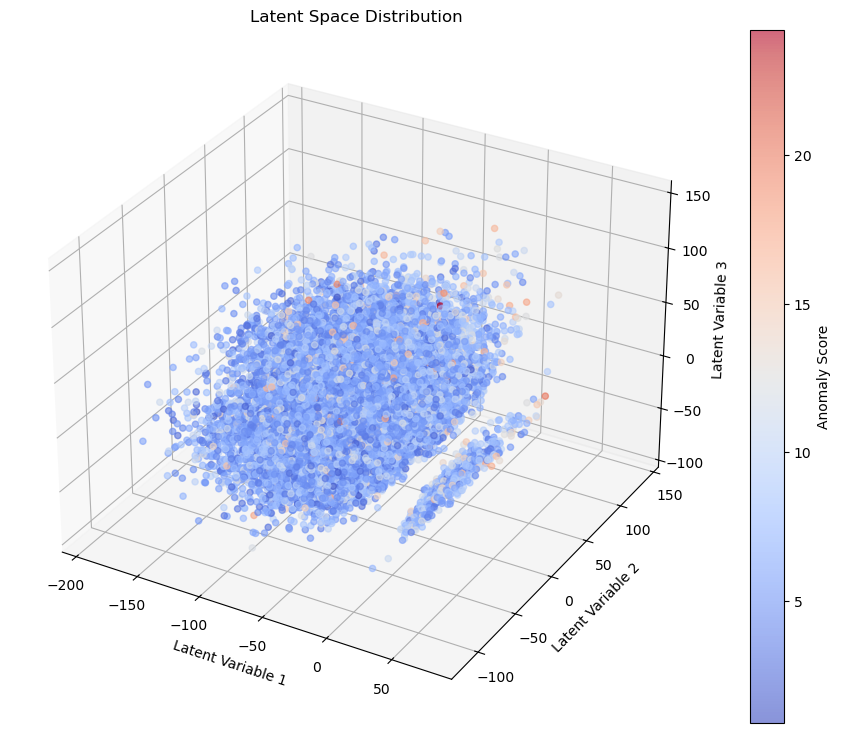

In [79]:
visualize_latent_space(
    fisher_ae, X_train_data, 
    y=fisher_errors_train,
    save_path='images/fisher/train_latent_space.png'
)

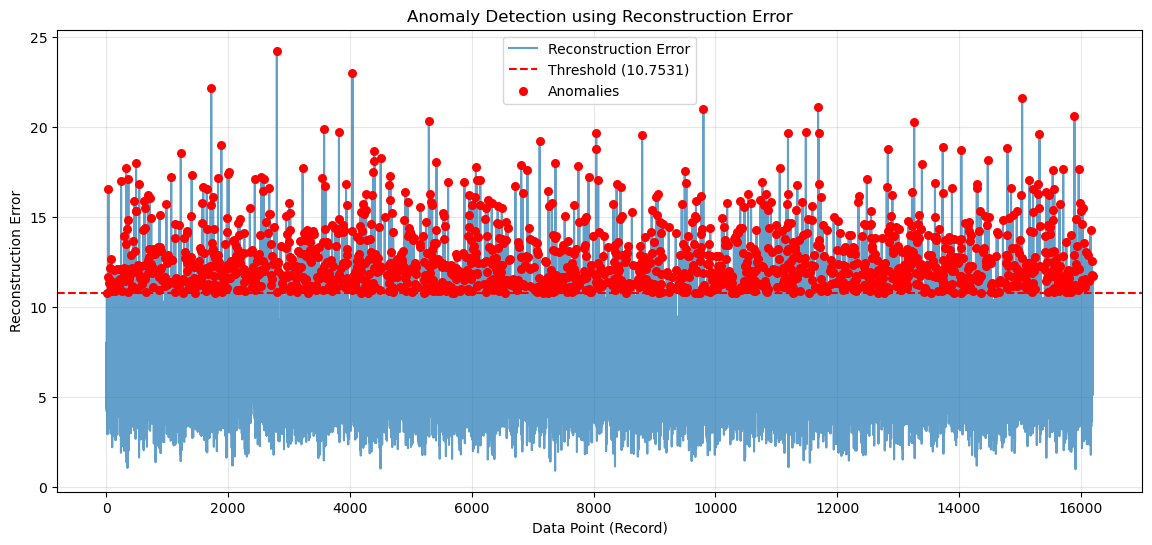

In [80]:
plot_reconstruction_errors(
    fisher_errors_train, fisher_threshold, fisher_is_anomaly_train,
    save_path='images/fisher/train_reconstruction_errors.png'
)

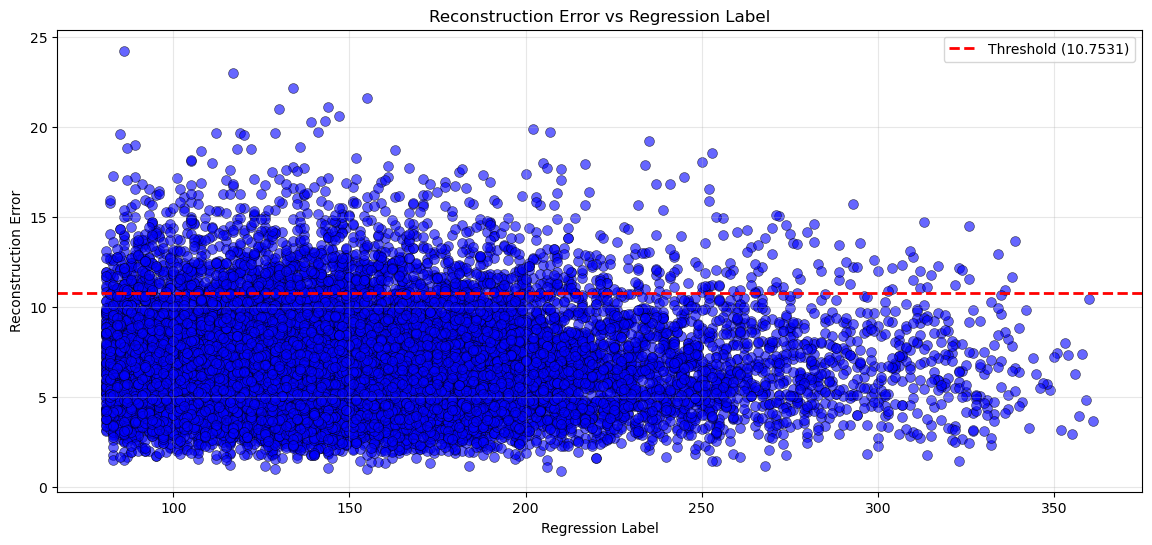

In [81]:
plot_error_vs_label(fisher_errors_train, y_train, threshold=fisher_threshold, save_path='images/fisher/train_error_vs_label.png')

### Test Set

In [82]:
fisher_errors_test, _, fisher_is_anomaly_test = detect_anomalies(
    fisher_ae, X_test_data, threshold=fisher_threshold
)

print(f"Test anomalies: {fisher_is_anomaly_test.sum()} / {len(fisher_is_anomaly_test)} ({100*fisher_is_anomaly_test.mean():.1f}%)")

Test anomalies: 2953 / 6330 (46.7%)


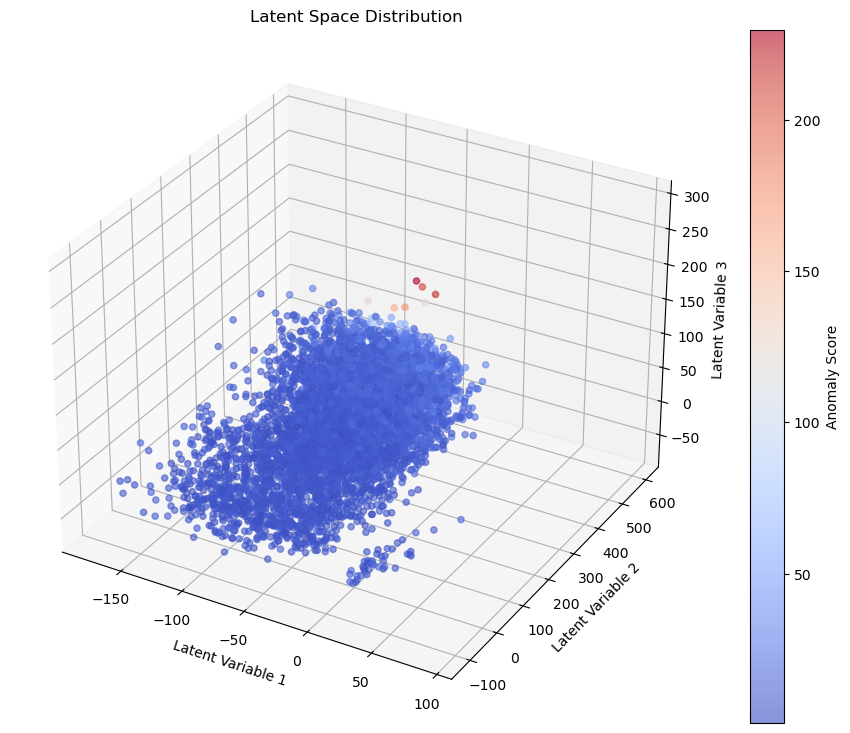

In [83]:
visualize_latent_space(
    fisher_ae, X_test_data, 
    y=fisher_errors_test,
    save_path='images/fisher/test_latent_space_test.png'
)

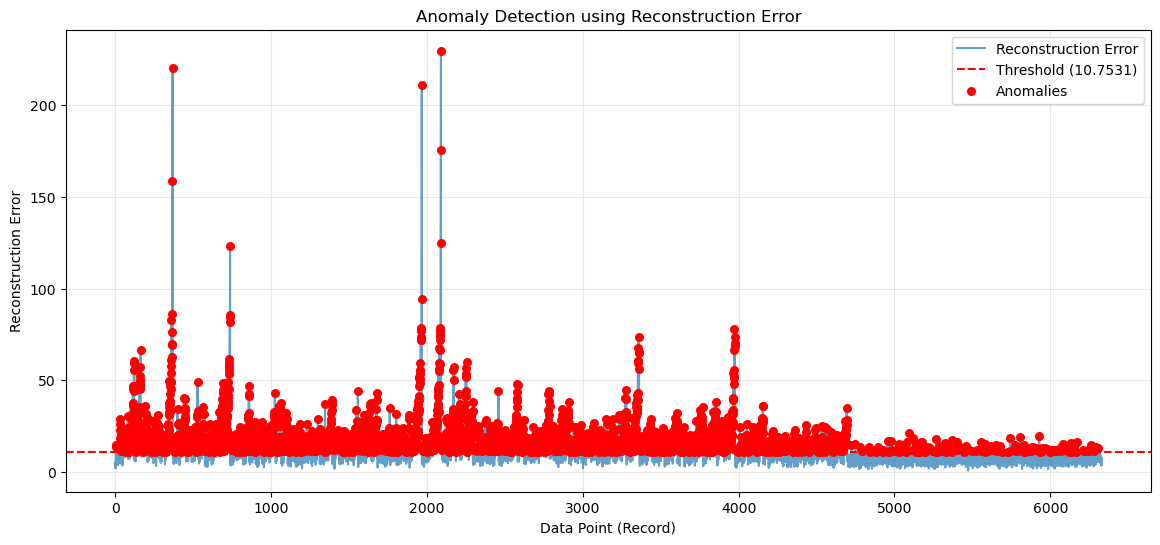

In [84]:
plot_reconstruction_errors(
    fisher_errors_test, fisher_threshold, fisher_is_anomaly_test,
    save_path='images/fisher/test_reconstruction_errors.png'
)

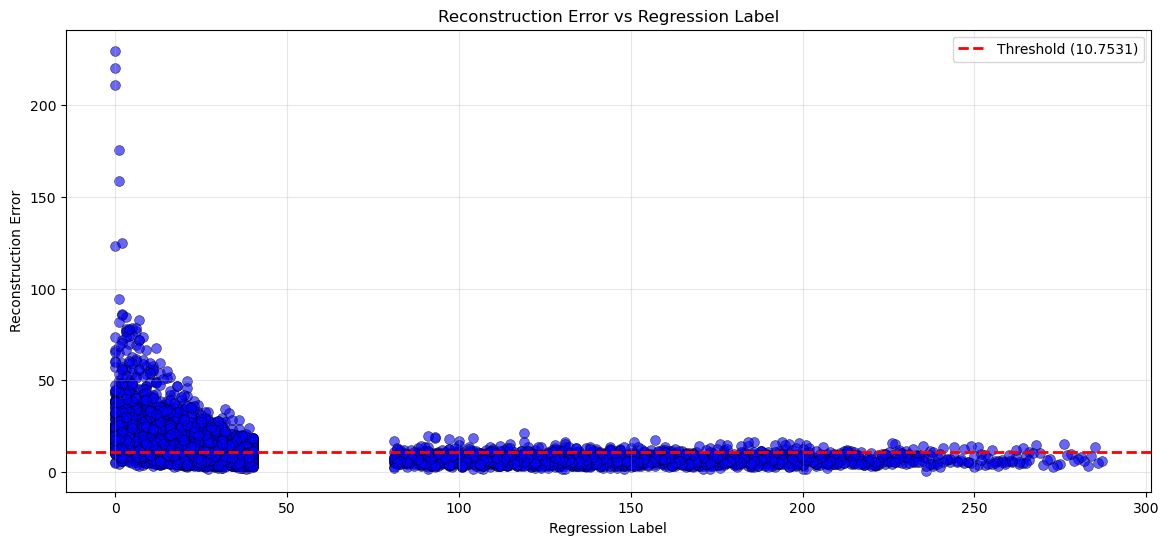

In [85]:
plot_error_vs_label(fisher_errors_test, y_test, threshold=fisher_threshold, save_path='images/fisher/test_error_vs_label.png')

In [86]:
from sklearn.metrics import precision_score, recall_score, f1_score

In [87]:
y_test_labels = (y_test <= 40)
y_test_labels

array([ True,  True,  True, ..., False, False, False], shape=(6330,))

In [88]:
print(f'Precision: {precision_score(y_test_labels, fisher_is_anomaly_test):.4f}')
print(f'Recall: {recall_score(y_test_labels, fisher_is_anomaly_test):.4f}')
print(f'F1 Score: {f1_score(y_test_labels, fisher_is_anomaly_test):.4f}')

Precision: 0.9397
Recall: 0.5909
F1 Score: 0.7256


## VAE

In [89]:
vae_errors_train, vae_threshold, vae_is_anomaly_train = detect_anomalies(
    vae, X_train_data, threshold_percentile=90
)

vae_n_anomalies = np.sum(vae_is_anomaly_train)
print(f"  Threshold: {vae_threshold:.4f}")
print(f"  Anomalies detected: {vae_n_anomalies}/{len(X_train_data)} ({100*vae_n_anomalies/len(X_train_data):.2f}%)")

  Threshold: 165644544.0000
  Anomalies detected: 1619/16195 (10.00%)


Los modelos se entrenaron con los parámetros que obtuvieron mejor resultado en el fine-tuning, por esa razón el espacio latente del VAE es de 2 y el de Fisher es de 3.

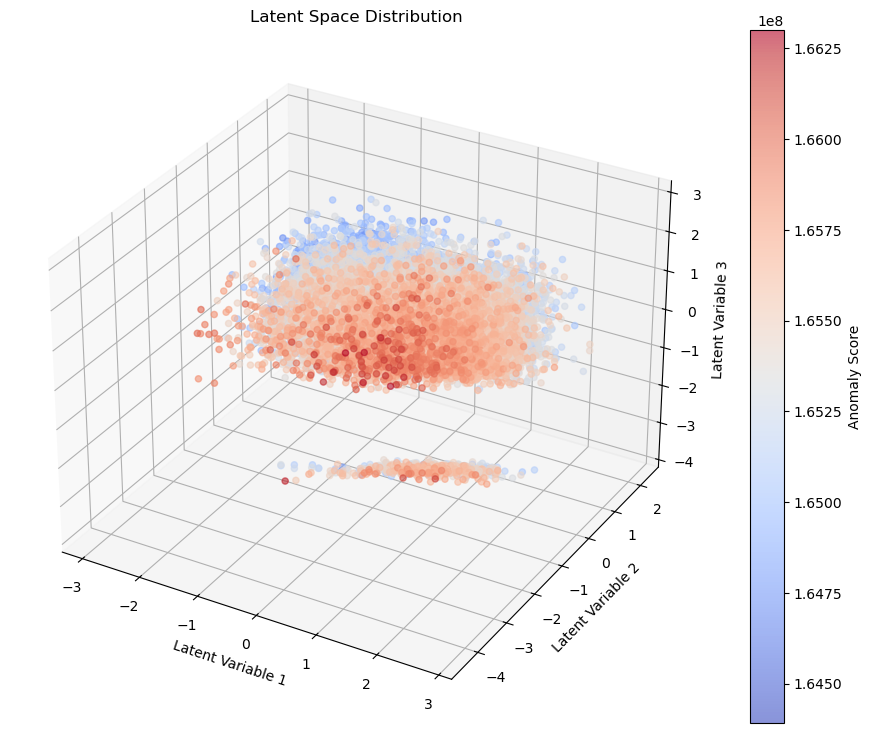

In [90]:
visualize_latent_space(
    vae, X_train_data, 
    y=vae_errors_train,
    save_path='images/vae/train_latent_space.png'
)

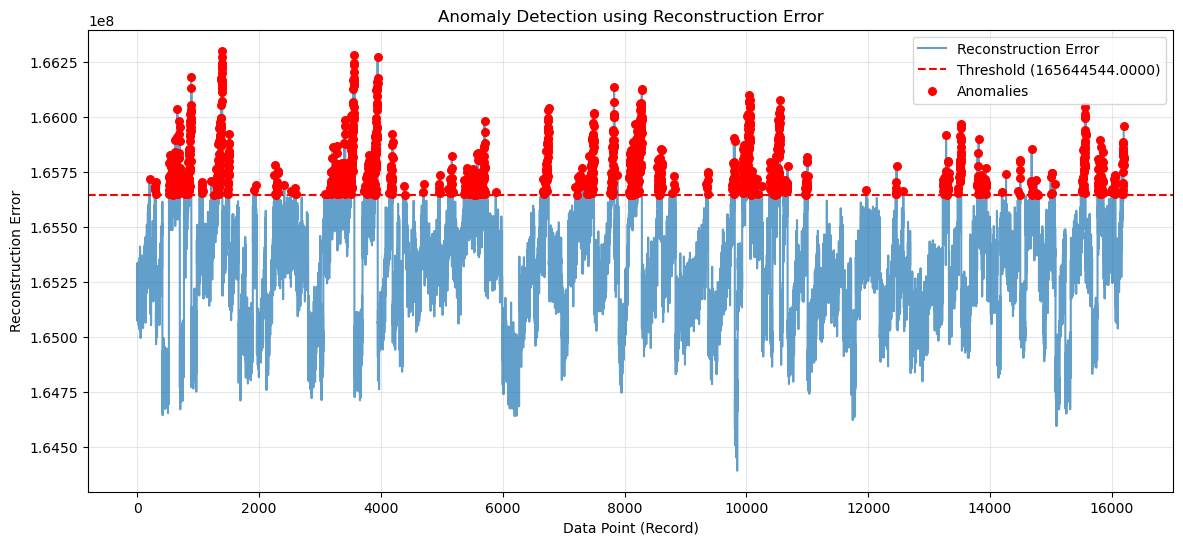

In [91]:
plot_reconstruction_errors(
    vae_errors_train, vae_threshold, vae_is_anomaly_train,
    save_path='images/vae/train_reconstruction_errors.png'
)

### Test set

In [93]:
vae_errors_test, _, vae_is_anomaly_test = detect_anomalies(
    vae, X_test_data, threshold=vae_threshold
)

vae_n_anomalies = np.sum(vae_is_anomaly_test)
print(f"  Threshold: {vae_threshold:.4f}")
print(f"  Anomalies detected: {vae_n_anomalies}/{len(X_test_data)} ({100*vae_n_anomalies/len(X_test_data):.2f}%)")

  Threshold: 165644544.0000
  Anomalies detected: 2560/6330 (40.44%)


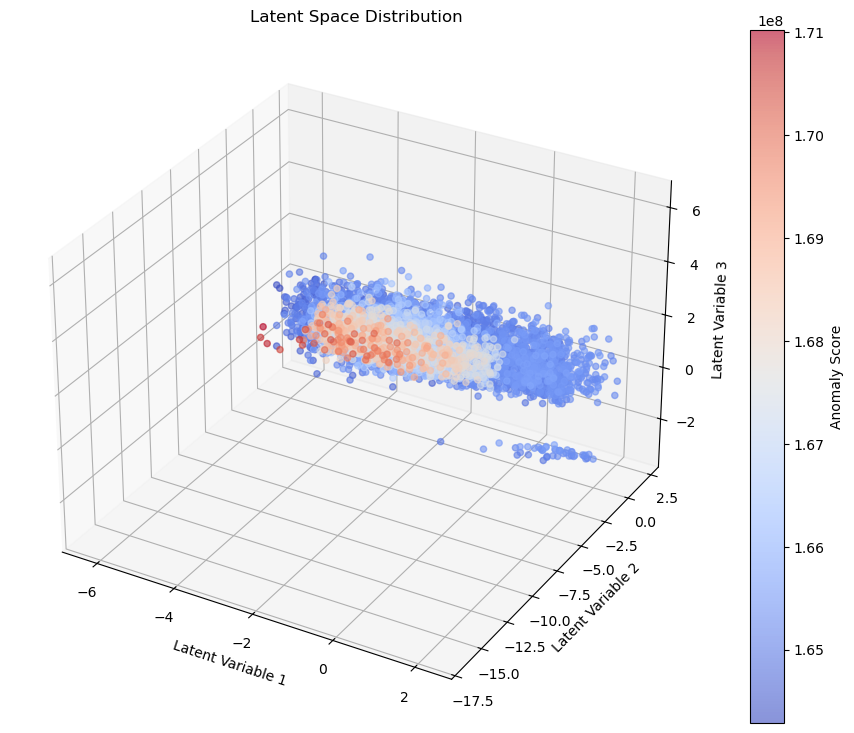

In [94]:
visualize_latent_space(
    vae, X_test_data, 
    y=vae_errors_test,
    save_path='images/vae/test_latent_space.png'
)

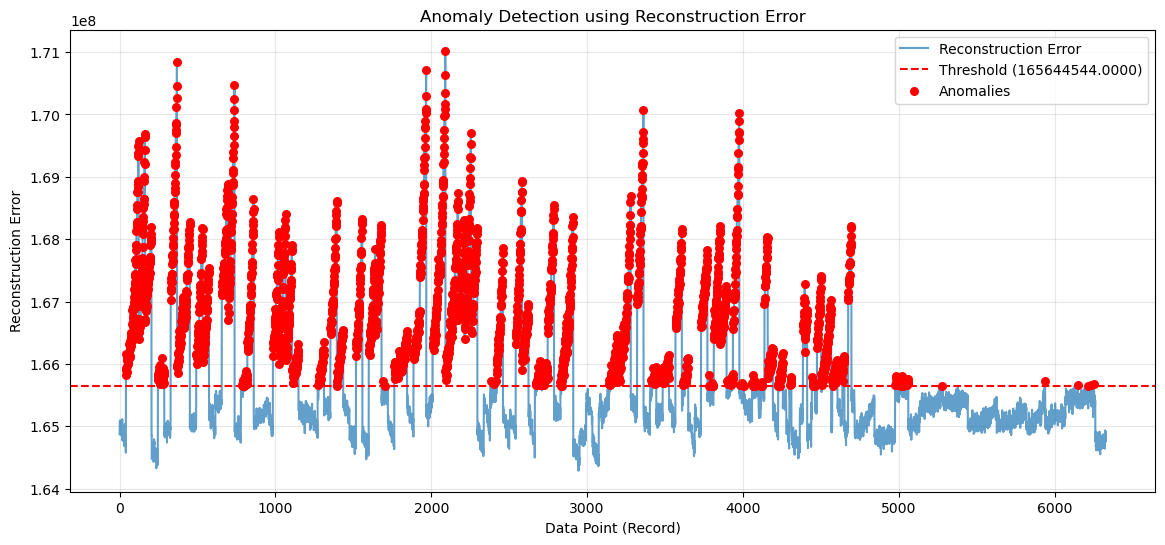

In [95]:
plot_reconstruction_errors(
    vae_errors_test, vae_threshold, vae_is_anomaly_test,
    save_path='images/vae/test_reconstruction_errors.png'
)

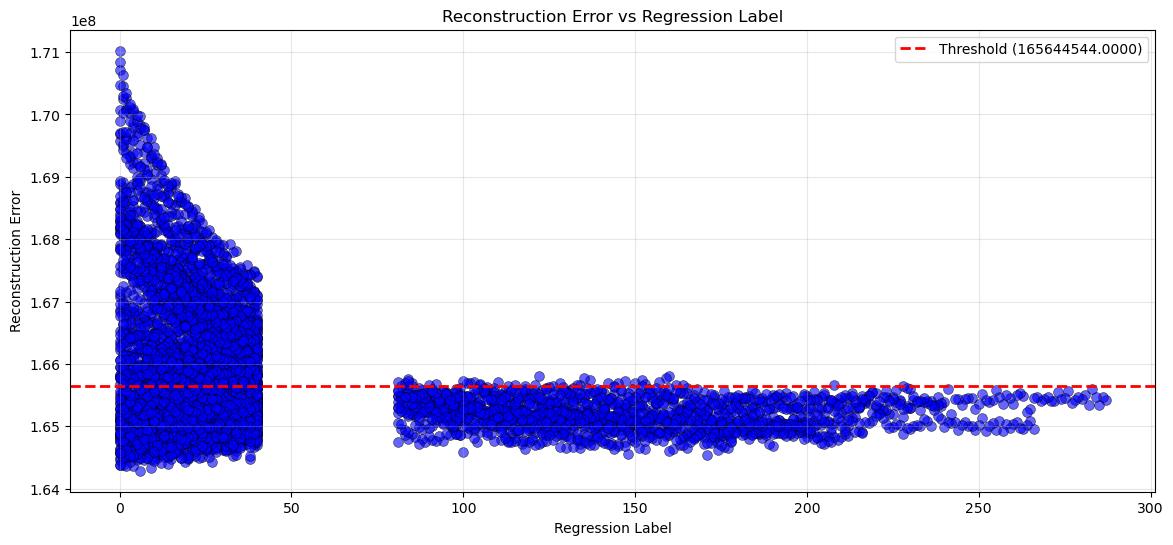

In [96]:
plot_error_vs_label(vae_errors_test, y_test, threshold=vae_threshold, save_path='images/vae/test_error_vs_label_vae.png')

In [97]:
print(f'Precision: {precision_score(y_test_labels, vae_is_anomaly_test):.4f}')
print(f'Recall: {recall_score(y_test_labels, vae_is_anomaly_test):.4f}')
print(f'F1 Score: {f1_score(y_test_labels, vae_is_anomaly_test):.4f}')

Precision: 0.9852
Recall: 0.5371
F1 Score: 0.6951


## Observaciones
El modelo VAE obtiene una precisión mayor al autoencoder de Fisher por 1.11%.

In [109]:
import json
import requests
from tensorflow_serving.apis.predict_pb2 import PredictRequest
import grpc
from tensorflow_serving.apis import prediction_service_pb2_grpc

In [103]:
X_train_data[0].size

20

In [106]:
dummy = np.zeros((1, 20), dtype=np.float32)
fisher_ae(dummy)
vae(dummy)

<tf.Tensor: shape=(1, 20), dtype=float32, numpy=
array([[nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
        nan, nan, nan, nan, nan, nan, nan]], dtype=float32)>

In [107]:
model_version = "1"
fisher_model_path = Path("models/fisher_cmapss") / model_version
vae_model_path = Path("models/vae_cmapss") / model_version
fisher_ae.export(fisher_model_path)
vae.export(vae_model_path)

INFO:tensorflow:Assets written to: models/fisher_cmapss/1/assets


INFO:tensorflow:Assets written to: models/fisher_cmapss/1/assets


Saved artifact at 'models/fisher_cmapss/1'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 20), dtype=tf.float32, name=None)
Output Type:
  TensorSpec(shape=(None, 20), dtype=tf.float32, name=None)
Captures:
  14028082512: TensorSpec(shape=(1, 20), dtype=tf.float32, name=None)
  14016525264: TensorSpec(shape=(1, 20), dtype=tf.float32, name=None)
  14028613312: TensorSpec(shape=(), dtype=tf.resource, name=None)
  14028610496: TensorSpec(shape=(), dtype=tf.resource, name=None)
  14028773984: TensorSpec(shape=(), dtype=tf.resource, name=None)
  14028771696: TensorSpec(shape=(), dtype=tf.resource, name=None)
  14028361040: TensorSpec(shape=(), dtype=tf.resource, name=None)
  14028775744: TensorSpec(shape=(), dtype=tf.resource, name=None)
  14028079520: TensorSpec(shape=(), dtype=tf.resource, name=None)
  14028083568: TensorSpec(shape=(), dtype=tf.resource, name=None)
INFO:tensorflow:Assets written to: models/vae_cmapss/1/asset

INFO:tensorflow:Assets written to: models/vae_cmapss/1/assets


Saved artifact at 'models/vae_cmapss/1'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 20), dtype=tf.float32, name=None)
Output Type:
  TensorSpec(shape=(None, 20), dtype=tf.float32, name=None)
Captures:
  14040054272: TensorSpec(shape=(1, 20), dtype=tf.float32, name=None)
  14040053040: TensorSpec(shape=(1, 20), dtype=tf.float32, name=None)
  14054432912: TensorSpec(shape=(), dtype=tf.resource, name=None)
  14054424816: TensorSpec(shape=(), dtype=tf.resource, name=None)
  14054534032: TensorSpec(shape=(), dtype=tf.resource, name=None)
  14054533680: TensorSpec(shape=(), dtype=tf.resource, name=None)
  14054529456: TensorSpec(shape=(), dtype=tf.resource, name=None)
  14054528752: TensorSpec(shape=(), dtype=tf.resource, name=None)
  14002551120: TensorSpec(shape=(), dtype=tf.resource, name=None)
  14040054624: TensorSpec(shape=(), dtype=tf.resource, name=None)


In [110]:
x_new = X_train_data[:10]
request_json = json.dumps({
    "signature_name": "serving_default",
    "instances": x_new.tolist(),
})

In [111]:
server_url="http://localhost:8501/v1/models/my_cmapss_model:predict"
response = requests.post(server_url, data=request_json)
response.raise_for_status()
response = response.json()

HTTPError: 403 Client Error: Forbidden for url: http://localhost:8501/v1/models/my_cmapss_model:predict

In [34]:
!saved_model_cli show --dir models/my_fisher_cmapss_model/1 --tag_set serve --signature_def serving_default

The given SavedModel SignatureDef contains the following input(s):
  inputs['input_1'] tensor_info:
      dtype: DT_FLOAT
      shape: (-1, 20)
      name: serving_default_input_1:0
The given SavedModel SignatureDef contains the following output(s):
  outputs['output_1'] tensor_info:
      dtype: DT_FLOAT
      shape: (-1, 20)
      name: StatefulPartitionedCall:0
Method name is: tensorflow/serving/predict


In [35]:
request = PredictRequest()
request.model_spec.name = "my_cmapss_model"
request.model_spec.signature_name = "serving_default"
input_name = "input_1"
request.inputs[input_name].CopyFrom(tf.make_tensor_proto(x_new))

In [38]:
channel = grpc.insecure_channel('localhost:8500')
predict_service = prediction_service_pb2_grpc.PredictionServiceStub(channel)
response = predict_service.Predict(request, timeout=10.0)